# 05 — Уровень как ФЕНОМЕН: реальные зоны vs случайные (контроль)

Сдвиг вопроса: не «есть ли торгуемый edge» (nb02-04 = нет), а «**реагирует ли рынок**
на уровень иначе, чем на случайную цену?». Гипотеза самосбывающегося пророчества:
люди следят за уровнями → на касании больше внимания (объём) и больше движения,
и это РАСТЁТ с «наблюдаемостью» уровня (сила = число касаний). Чистая случайность →
реальные ≈ фейковые, плоский dose-response.

**Контроль:** берём реальные cluster-зоны и меняем только ЦЕНУ на случайную из того же
окна (то же число, то же время). Сравниваем объём и пост-движение на касании.
Без издержек/PnL — чистый феномен. Микроструктура (стакан) вне скоупа.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
import pandas as pd
rng = np.random.default_rng(0)

full = [s for s in sorted(p.name for p in loader.DATA_ROOT.iterdir() if p.is_dir())
        if len(list((loader.DATA_ROOT / s).glob("*.parquet"))) >= 28]
UNIV = full[::3][:50]
START, END, TF = "2024-01-01", "2025-07-01", "1h"
TOL = 0.0015; CD = 6; LIFE = 720; NPOST = 12
print(len(UNIV), "symbols")

47 symbols


In [2]:
def pivots(df, k):
    h = df["high"].to_numpy(); l = df["low"].to_numpy(); n = len(df)
    hi = np.zeros(n, bool); lo = np.zeros(n, bool)
    for i in range(k, n - k):
        wH = h[i - k:i + k + 1]; wL = l[i - k:i + k + 1]
        if h[i] == wH.max() and (wH == h[i]).sum() == 1: hi[i] = True
        if l[i] == wL.min() and (wL == l[i]).sum() == 1: lo[i] = True
    return hi, lo

def cluster_segments(df, k=10, R=24, life=LIFE, tol=0.006, mint=3):
    hi, lo = pivots(df, k); n = len(df)
    h = df["high"].to_numpy(); l = df["low"].to_numpy(); conf = []
    for i in np.where(hi)[0]: conf.append((i + k, h[i]))
    for i in np.where(lo)[0]: conf.append((i + k, l[i]))
    conf = np.array(sorted(conf)) if conf else np.empty((0, 2)); segs = []
    for r in range(k, n, R):
        if len(conf) == 0: break
        m = (conf[:, 0] <= r) & (conf[:, 0] > r - life); px = np.sort(conf[m, 1])
        if len(px) < mint: continue
        cl = [[px[0]]]
        for x in px[1:]:
            if (x - cl[-1][0]) / cl[-1][0] <= tol: cl[-1].append(x)
            else: cl.append([x])
        for c in cl:
            if len(c) >= mint: segs.append((float(np.mean(c)), r, min(r + R, n), len(c)))
    return segs

def fake_segments(df, segs):
    """Same count/timing/strength, price randomised to a value the bar actually
    visits in [a,b] (drawn from close) so touch frequency is comparable."""
    c = df["close"].to_numpy(); out = []
    for L, a, b, strg in segs:
        out.append((float(rng.choice(c[a:b])), a, b, strg))
    return out

def touches(df, segs, tol=TOL):
    c = df["close"].to_numpy(); h = df["high"].to_numpy(); l = df["low"].to_numpy()
    best = {}
    for L, a, b, strg in segs:
        a = max(a, 1)
        for t in range(a, b):
            if c[t-1] < L*(1-tol) and h[t] >= L*(1-tol):
                d = abs(h[t]-L)/L; key=(t,"res")
                if key not in best or d < best[key][1]: best[key] = (d, strg)
            elif c[t-1] > L*(1+tol) and l[t] <= L*(1+tol):
                d = abs(l[t]-L)/L; key=(t,"sup")
                if key not in best or d < best[key][1]: best[key] = (d, strg)
    out = sorted((t, side, strg) for (t, side), (d, strg) in best.items())
    kept = []; last = -10**9
    for t, side, strg in out:
        if t - last >= CD: kept.append((t, side, strg)); last = t
    return kept

In [3]:
rows = []
for si, sym in enumerate(UNIV):
    df = ohlcv(sym, START, END, TF)
    if len(df) < 300: continue
    c = df["close"].to_numpy(); v = df["volume"].to_numpy(); n = len(df)
    vmed = pd.Series(v).rolling(168, min_periods=24).median().to_numpy()  # weekly median vol
    rvol = pd.Series(c).pct_change().rolling(24).std().to_numpy()         # pre-touch regime vol
    real = cluster_segments(df)
    for kind, segs in [("real", real), ("fake", fake_segments(df, real))]:
        for t, side, strg in touches(df, segs):
            if t < 168 or t + NPOST >= n or not vmed[t] > 0: continue
            fwd = np.abs(c[t+1:t+1+NPOST] / c[t] - 1.0)
            rows.append(dict(kind=kind, strg=strg,
                             vsurge=v[t]/vmed[t],
                             premove=np.nan if not rvol[t] > 0 else rvol[t]*100,
                             postmax=fwd.max()*100, postmean=fwd.mean()*100))
    if (si+1) % 15 == 0: print(f"  {si+1}/{len(UNIV)}")

E = pd.DataFrame(rows)
print("\nevents:", E.kind.value_counts().to_dict())
summ = E.groupby("kind").agg(n=("vsurge","size"),
    vsurge_med=("vsurge","median"), vsurge_mean=("vsurge","mean"),
    postmax_med=("postmax","median"), postmean_med=("postmean","median"),
    premove_med=("premove","median"))
print(summ.round(3).to_string())

  15/47


  30/47


  45/47



events: {'fake': 82909, 'real': 26408}
          n  vsurge_med  vsurge_mean  postmax_med  postmean_med  premove_med
kind                                                                        
fake  82909       1.059        2.501        2.683         1.233        0.873
real  26408       1.332        3.251        2.585         1.238        0.782


## След внимания и реакции: real vs fake, и dose-response по силе

[saved] notebooks\levels\_out\05_phenomenon.png


WindowsPath('C:/projects/researchlab/notebooks/levels/_out/05_phenomenon.png')

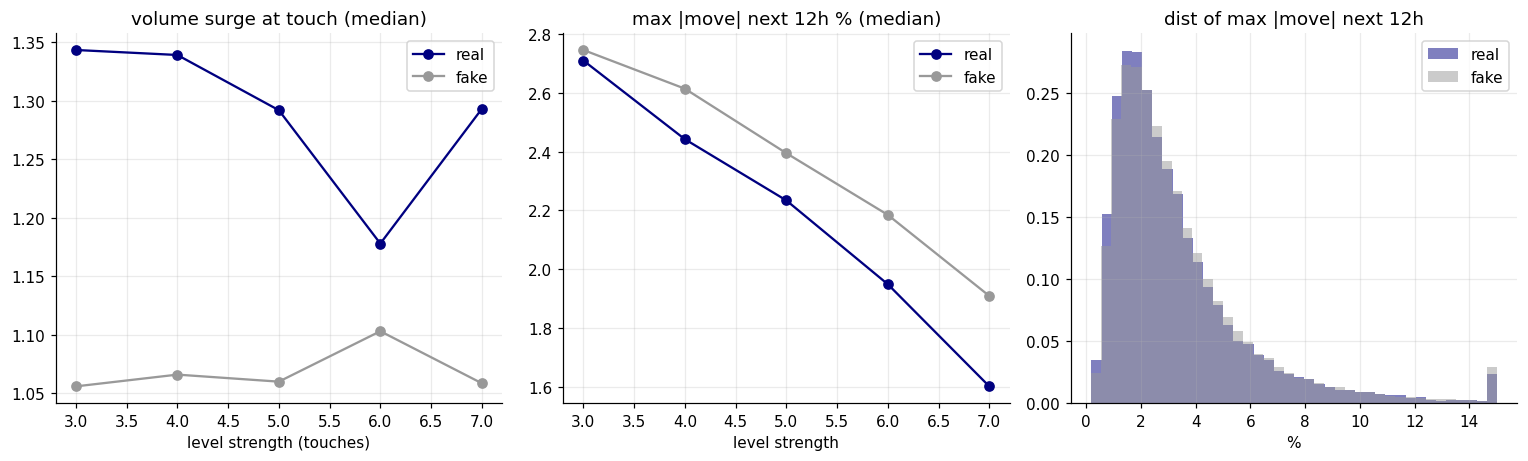

In [4]:
E["sbin"] = np.clip(E["strg"], 3, 7)
ds = E.groupby(["kind", "sbin"]).agg(n=("vsurge","size"), vsurge=("vsurge","median"),
                                      postmax=("postmax","median")).reset_index()

fig, ax = plt.subplots(1, 3, figsize=(14, 4.3))
for k, col in [("real", "navy"), ("fake", "0.6")]:
    g = ds[ds.kind == k]
    ax[0].plot(g.sbin, g.vsurge, "o-", color=col, label=k)
    ax[1].plot(g.sbin, g.postmax, "o-", color=col, label=k)
ax[0].set_title("volume surge at touch (median)"); ax[0].set_xlabel("level strength (touches)"); ax[0].legend()
ax[1].set_title(f"max |move| next {NPOST}h % (median)"); ax[1].set_xlabel("level strength"); ax[1].legend()
# distributions of post-move real vs fake
ax[2].hist(E[E.kind=="real"].postmax.clip(upper=15), bins=40, density=True, alpha=0.5, color="navy", label="real")
ax[2].hist(E[E.kind=="fake"].postmax.clip(upper=15), bins=40, density=True, alpha=0.5, color="0.6", label="fake")
ax[2].set_title(f"dist of max |move| next {NPOST}h"); ax[2].set_xlabel("%"); ax[2].legend()
show("05_phenomenon")

## Как читать / verdict

- **real > fake** на объёме/пост-движении ⇒ уровень — реальный след внимания (феномен
  есть, хоть и не торгуем направленно).
- **dose-response вверх** по силе (real растёт, fake плоский) ⇒ подпись
  самосбывающегося пророчества: чем больше следят, тем сильнее реакция.
- **real ≈ fake** ⇒ даже следа нет в 1h OHLCV → феномен (если есть) живёт в
  микроструктуре. Оговорка: fake-уровень тоже попадает в зоны, где цена бывала
  (по построению) — это консервативный, честный контроль.